In [1]:
import os
os.chdir(r'C:\Users\arif\OneDrive - Higher Education Commission\Teaching\Courses\machine learning\Spring 2026\Code')

In [2]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, explained_variance_score, r2_score
from timeseires.utils.to_split import to_split
from timeseires.utils.multivariate_multi_step import multivariate_multi_step
from timeseires.utils.multivariate_single_step import multivariate_single_step
from timeseires.utils.univariate_multi_step import univariate_multi_step
from timeseires.utils.univariate_single_step import univariate_single_step
from timeseires.utils.CosineAnnealingLRS import CosineAnnealingLRS
from timeseires.callbacks.EpochCheckpoint import EpochCheckpoint
from tensorflow.keras.callbacks import ModelCheckpoint
from timeseires.callbacks.TrainingMonitor import TrainingMonitor
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import LSTM, Bidirectional, Add
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Conv1D,TimeDistributed
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten,MaxPooling1D,Concatenate,AveragePooling1D, GlobalMaxPooling1D, Input
from tensorflow.keras.models import Sequential,Model
import pandas as pd
import time, pickle
import numpy as np
import tensorflow.keras.backend as K
import tensorflow
from tensorflow.keras.layers import Input, Reshape, Lambda
from tensorflow.keras.layers import Layer, Flatten, LeakyReLU, concatenate, Dense
from tensorflow.keras.regularizers import l2
import glob
import h5py
import matplotlib.pyplot as plt
from keras.callbacks import Callback

Using TensorFlow backend.


In [3]:
#lookback = 24
model = None
start_epoch = 0
time_steps=24
num_features=21

In [4]:
def MLP():
    model = Sequential()
    model.add(Flatten(input_shape=(time_steps , num_features)))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1))
    return model

In [5]:
model1 = MLP()
model1.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten (Flatten)            (None, 504)               0         
_________________________________________________________________
dense (Dense)                (None, 32)                16160     
_________________________________________________________________
dense_1 (Dense)              (None, 1)                 33        
Total params: 16,193
Trainable params: 16,193
Non-trainable params: 0
_________________________________________________________________


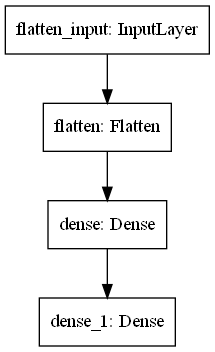

In [6]:
tensorflow.keras.utils.plot_model(model1 )

In [7]:
checkpoints = r'C:\Users\arif\Downloads\delete\E1-cp-{epoch:04d}-loss{val_loss:.2f}.h5'
OUTPUT_PATH = r'C:\Users\arif\Downloads\delete'
FIG_PATH = os.path.sep.join([OUTPUT_PATH,"\history.png"])
JSON_PATH = os.path.sep.join([OUTPUT_PATH,"\history.json"])

In [8]:
os.path.exists(JSON_PATH)

False

In [9]:
# construct the callback to save only the *best* model to disk
# based on the validation loss
EpochCheckpoint1 = ModelCheckpoint(checkpoints,
                             monitor="val_loss",
                             save_best_only=True, 
                             verbose=1)
TrainingMonitor1=TrainingMonitor(FIG_PATH, jsonPath=JSON_PATH, startAt=start_epoch)

# construct the set of callbacks
callbacks = [EpochCheckpoint1,TrainingMonitor1]

In [10]:
# if there is no specific model checkpoint supplied, then initialize
# the network and compile the model
if model is None:
    print("[INFO] compiling model...")
    model =MLP()
    opt = Adam(1e-3)
    model.compile(loss= 'mae', optimizer=opt, metrics=["mae", "mape"])
# otherwise, load the checkpoint from disk
else:
    print("[INFO] loading {}...".format(model))
    model = load_model(model)

    # update the learning rate
    print("[INFO] old learning rate: {}".format(K.get_value(model.optimizer.lr)))
    K.set_value(model.optimizer.lr, 1e-4)
    print("[INFO] new learning rate: {}".format(K.get_value(model.optimizer.lr)))

[INFO] compiling model...


In [11]:
import os
path_dataset =r'C:\Users\arif\OneDrive - Higher Education Commission\Teaching\Courses\machine learning\Spring 2026\Code'
path_tr = os.path.join(path_dataset, 'train.csv')
df_tr = pd.read_csv(path_tr)
train_set = df_tr.iloc[:].values
path_v = os.path.join(path_dataset, 'validation.csv')
df_v = pd.read_csv(path_v)
validation_set = df_v.iloc[:].values 
path_te = os.path.join(path_dataset, 'test.csv')
df_te = pd.read_csv(path_te)
test_set = df_te.iloc[:].values 

path_scaler = os.path.join(path_dataset, 'AEPscaler.pkl')
scaler         = pickle.load(open(path_scaler, 'rb'))

train_set.shape, validation_set.shape, test_set.shape

((860, 21), (90, 21), (30, 21))

In [12]:
start = time.time()
train_X , train_y = univariate_multi_step(train_set, time_steps, target_col=0,target_len=1)
validation_X, validation_y = univariate_multi_step(validation_set, time_steps, target_col=0,target_len=1)
test_X, test_y = univariate_multi_step(test_set, time_steps, target_col=0,target_len=1)
print('Time Consumed', time.time()-start, "sec")

Time Consumed 0.0029668807983398438 sec


In [13]:
train_X.shape

(835, 24, 21)

In [14]:
epochs = 60
verbose = 1 #0
batch_size = 32
History = model.fit(train_X,
                        train_y,
                        batch_size=batch_size,   
                        epochs = epochs, 
                        validation_data = (validation_X,validation_y),
                        callbacks=callbacks,
                    verbose = verbose)

Train on 835 samples, validate on 65 samples
Epoch 1/60
736/835 [=========================>....] - ETA: 0s - loss: 0.1533 - mae: 0.1533 - mape: 101.4162
Epoch 00001: val_loss improved from inf to 0.06624, saving model to C:\Users\arif\Downloads\delete\E1-cp-0001-loss0.07.h5
835/835 [==============================] - 1s 1ms/sample - loss: 0.1429 - mae: 0.1429 - mape: 91.8888 - val_loss: 0.0662 - val_mae: 0.0662 - val_mape: 20.3803
Epoch 2/60
576/835 [===================>..........] - ETA: 0s - loss: 0.0826 - mae: 0.0826 - mape: 49.8207
Epoch 00002: val_loss improved from 0.06624 to 0.05364, saving model to C:\Users\arif\Downloads\delete\E1-cp-0002-loss0.05.h5
835/835 [==============================] - 9s 11ms/sample - loss: 0.0833 - mae: 0.0833 - mape: 45.2768 - val_loss: 0.0536 - val_mae: 0.0536 - val_mape: 18.6018
Epoch 3/60
512/835 [=================>............] - ETA: 0s - loss: 0.0725 - mae: 0.0725 - mape: 37.4328
Epoch 00003: val_loss did not improve from 0.05364
835/835 [======

In [15]:

model = load_model(r'C:\Users\arif\Downloads\delete\E1-cp-0055-loss0.03.h5')

y_pred_scaled   = model.predict(test_X)
y_pred          = scaler.inverse_transform(y_pred_scaled)
y_test_unscaled = scaler.inverse_transform(test_y)
# Mean Absolute Error (MAE)
MAE = np.mean(abs(y_pred - y_test_unscaled)) 
print('Mean Absolute Error (MAE): ' + str(np.round(MAE, 2)))

# Median Absolute Error (MedAE)
MEDAE = np.median(abs(y_pred - y_test_unscaled))
print('Median Absolute Error (MedAE): ' + str(np.round(MEDAE, 2)))

# Mean Squared Error (MSE)
MSE = np.square(np.subtract(y_pred, y_test_unscaled)).mean()
print('Mean Squared Error (MSE): ' + str(np.round(MSE, 2)))

# Root Mean Squarred Error (RMSE) 
RMSE = np.sqrt(np.mean(np.square(y_pred - y_test_unscaled)))
print('Root Mean Squared Error (RMSE): ' + str(np.round(RMSE, 2)))

# Mean Absolute Percentage Error (MAPE)
MAPE = np.mean((np.abs(np.subtract(y_test_unscaled, y_pred)/ y_test_unscaled))) * 100
print('Mean Absolute Percentage Error (MAPE): ' + str(np.round(MAPE, 2)) + ' %')

# Median Absolute Percentage Error (MDAPE)
MDAPE = np.median((np.abs(np.subtract(y_test_unscaled, y_pred)/ y_test_unscaled))) * 100
print('Median Absolute Percentage Error (MDAPE): ' + str(np.round(MDAPE, 2)) + ' %')

print('\n\ny_test_unscaled.shape= ',y_test_unscaled.shape)
print('y_pred.shape= ',y_pred.shape)

Mean Absolute Error (MAE): 12401.71
Median Absolute Error (MedAE): 12529.37
Mean Squared Error (MSE): 153967995.29
Root Mean Squared Error (RMSE): 12408.38
Mean Absolute Percentage Error (MAPE): 79.25 %
Median Absolute Percentage Error (MDAPE): 79.69 %


y_test_unscaled.shape=  (5, 1)
y_pred.shape=  (5, 1)


# Fine Tuning

In [20]:
checkpoints = r'C:\Users\arif\Downloads\delete\E2-cp-{epoch:04d}-loss{val_loss:.2f}.h5'
model=r'C:\Users\arif\Downloads\delete\E1-cp-0055-loss0.03.h5'
start_epoch= 56

In [21]:
# construct the callback to save only the *best* model to disk
# based on the validation loss
EpochCheckpoint1 = ModelCheckpoint(checkpoints,
                             monitor="val_loss",
                             save_best_only=True, 
                             verbose=1)
TrainingMonitor1=TrainingMonitor(FIG_PATH, jsonPath=JSON_PATH, startAt=start_epoch)

# construct the set of callbacks
callbacks = [EpochCheckpoint1,TrainingMonitor1]
# if there is no specific model checkpoint supplied, then initialize
# the network and compile the model
if model is None:
    print("[INFO] compiling model...")
    model = PC.build(time_steps=24, num_features=21, reg=0.0005)
    opt = Adam(1e-3)
    model.compile(loss= 'mae', optimizer=opt, metrics=["mae", "mape"])
# otherwise, load the checkpoint from disk
else:
    print("[INFO] loading {}...".format(model))
    model = load_model(model)

    # update the learning rate
    print("[INFO] old learning rate: {}".format(K.get_value(model.optimizer.lr)))
    K.set_value(model.optimizer.lr, 1e-4)
    print("[INFO] new learning rate: {}".format(K.get_value(model.optimizer.lr)))

[INFO] loading C:\Users\arif\Downloads\delete\E1-cp-0055-loss0.03.h5...
[INFO] old learning rate: 0.0010000000474974513
[INFO] new learning rate: 9.999999747378752e-05


In [22]:
epochs = 10
verbose = 1 #0
batch_size = 32
History = model.fit(train_X,
                        train_y,
                        batch_size=batch_size,   
                        epochs = epochs, 
                        validation_data = (validation_X,validation_y),
                        callbacks=callbacks,
                        verbose = verbose)

Train on 835 samples, validate on 65 samples
Epoch 1/10
672/835 [=======================>......] - ETA: 0s - loss: 0.0220 - mae: 0.0220 - mape: 9.3523 
Epoch 00001: val_loss improved from inf to 0.03299, saving model to C:\Users\arif\Downloads\delete\E2-cp-0001-loss0.03.h5
835/835 [==============================] - 1s 623us/sample - loss: 0.0213 - mae: 0.0213 - mape: 9.0533 - val_loss: 0.0330 - val_mae: 0.0330 - val_mape: 9.9388
Epoch 2/10
384/835 [============>.................] - ETA: 0s - loss: 0.0182 - mae: 0.0182 - mape: 7.2160
Epoch 00002: val_loss improved from 0.03299 to 0.03287, saving model to C:\Users\arif\Downloads\delete\E2-cp-0002-loss0.03.h5
835/835 [==============================] - 0s 239us/sample - loss: 0.0176 - mae: 0.0176 - mape: 7.8068 - val_loss: 0.0329 - val_mae: 0.0329 - val_mape: 10.0569
Epoch 3/10
576/835 [===================>..........] - ETA: 0s - loss: 0.0170 - mae: 0.0170 - mape: 6.8712
Epoch 00003: val_loss improved from 0.03287 to 0.02768, saving model 

In [23]:

model = load_model(r'C:\Users\arif\Downloads\delete\E1-cp-0055-loss0.03.h5')

y_pred_scaled   = model.predict(test_X)
y_pred          = scaler.inverse_transform(y_pred_scaled)
y_test_unscaled = scaler.inverse_transform(test_y)
# Mean Absolute Error (MAE)
MAE = np.mean(abs(y_pred - y_test_unscaled)) 
print('Mean Absolute Error (MAE): ' + str(np.round(MAE, 2)))

# Median Absolute Error (MedAE)
MEDAE = np.median(abs(y_pred - y_test_unscaled))
print('Median Absolute Error (MedAE): ' + str(np.round(MEDAE, 2)))

# Mean Squared Error (MSE)
MSE = np.square(np.subtract(y_pred, y_test_unscaled)).mean()
print('Mean Squared Error (MSE): ' + str(np.round(MSE, 2)))

# Root Mean Squarred Error (RMSE) 
RMSE = np.sqrt(np.mean(np.square(y_pred - y_test_unscaled)))
print('Root Mean Squared Error (RMSE): ' + str(np.round(RMSE, 2)))

# Mean Absolute Percentage Error (MAPE)
MAPE = np.mean((np.abs(np.subtract(y_test_unscaled, y_pred)/ y_test_unscaled))) * 100
print('Mean Absolute Percentage Error (MAPE): ' + str(np.round(MAPE, 2)) + ' %')

# Median Absolute Percentage Error (MDAPE)
MDAPE = np.median((np.abs(np.subtract(y_test_unscaled, y_pred)/ y_test_unscaled))) * 100
print('Median Absolute Percentage Error (MDAPE): ' + str(np.round(MDAPE, 2)) + ' %')

print('\n\ny_test_unscaled.shape= ',y_test_unscaled.shape)
print('y_pred.shape= ',y_pred.shape)

Mean Absolute Error (MAE): 12401.71
Median Absolute Error (MedAE): 12529.37
Mean Squared Error (MSE): 153967995.29
Root Mean Squared Error (RMSE): 12408.38
Mean Absolute Percentage Error (MAPE): 79.25 %
Median Absolute Percentage Error (MDAPE): 79.69 %


y_test_unscaled.shape=  (5, 1)
y_pred.shape=  (5, 1)
